# New England — Model Evaluation

Evaluates the trained Faraday model against the plan's five fidelity criteria:

| # | Criterion | Threshold | Reference |
|---|---|---|---|
| 1 | Mean annual kWh per home | within ±5 % | RECS 2020 weighted NE mean |
| 2 | Seasonal aggregate peak timing | within 60 min | ISO-NE hourly demand (2019, fixed EST) |
| 3 | Seasonal mean profile shape | Pearson r > 0.85 | EULP holdout split |
| 4 | EV evening signature | evening (16–23 h) energy-share uplift for EV homes | internal contrast |
| 5 | PV signature | midday net-load depression in `has_pv` homes; shapes within ~10 % of the NSRDB climatology | PVWatts-model shapes (Open-Meteo 2018, PVGIS cross-check) |

Synthetic profiles are generated by conditioning on the **holdout** homes' real label
trajectories (their actual month / dayofweek / temp_bin sequences), then compared per
criterion. The holdout split shares no buildings with training.

The final sections align the evaluation with the LF Energy framework of Chai et al. 2024,
*Defining 'Good': Evaluation Framework for Synthetic Smart Meter Data*
([arXiv:2407.11785](https://arxiv.org/abs/2407.11785)) — **fidelity / utility / privacy** —
reusing the evaluation tooling that already ships in this repo
(`opensynth.evaluation.fidelity.{seasonal_statistics,autocorrelation}`,
`opensynth.evaluation.privacy`).

In [1]:
import ast
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch

from opensynth.datasets.new_england import config
from opensynth.datasets.new_england.faraday_ne import NewEnglandFaradayModel
from opensynth.models.faraday.gaussian_mixture import GaussianMixtureModel
from opensynth.models.faraday.vae_model import FaradayVAE

torch.manual_seed(0)

DATA_DIR = Path("../../data")
MODEL_DIR = DATA_DIR / "models/new_england"
GMM_K = 200  # pick from the sweep {100, 200, 400}


def load_ne_model(k):
    """Rebuild a NewEnglandFaradayModel from the training checkpoints."""
    vae = FaradayVAE.load_from_checkpoint(
        MODEL_DIR / "ne_vae.ckpt", map_location="cpu"
    )
    meta = json.loads((MODEL_DIR / "ne_vae_meta.json").read_text())
    vae.feature_list = meta["feature_list"]
    vae.eval()
    ckpt = torch.load(MODEL_DIR / f"ne_gmm_{k}.pt", map_location="cpu")
    gmm = GaussianMixtureModel(
        num_components=k,
        num_features=vae.latent_dim + len(meta["feature_list"]),
        reg_covar=ckpt["covariance_reg"],
    )
    state = dict(ckpt["gmm_state_dict"])
    state["nll"] = state["nll"].reshape(1)  # EM saves a 0-dim nll buffer
    gmm.load_state_dict(state)
    model = NewEnglandFaradayModel(
        vae_module=vae, n_components=k, covariance_reg=ckpt["covariance_reg"]
    )
    model.gmm_module = gmm
    model.feature_range = ckpt["feature_range"]
    return model, meta


def generate_matched(model, df_labels: pl.DataFrame) -> np.ndarray:
    """One synthetic day per row, batched over unique label combinations."""
    feats = list(config.FEATURE_COLS)
    out = np.empty((df_labels.height, 96), dtype=np.float32)
    pdf = df_labels.select(feats).to_pandas()
    for key, idx in pdf.groupby(feats).indices.items():
        labels = dict(zip(feats, (float(v) for v in key)))
        with torch.no_grad():
            sampled = model.sample_gmm_conditional(labels, len(idx))
        kwh = sampled["kwh"].numpy() * KWH_STD + KWH_MEAN
        if labels["has_pv"] == 0:
            # Net load may go negative only for PV homes (export)
            kwh = kwh.clip(min=0)
        out[idx] = kwh
    return out


model, meta = load_ne_model(GMM_K)
stats = pl.read_csv(DATA_DIR / "processed/new_england/train/mean_std.csv")
KWH_MEAN, KWH_STD = stats["mean"][0], stats["stdev"][0]
print("Model loaded. Features:", meta["feature_list"])
print(f"VAE final training loss: {meta['epoch_losses'][-1]:.3f}")


Model loaded. Features: ['state', 'archetype', 'heating_fuel', 'has_ev', 'has_pv', 'month', 'dayofweek', 'temp_bin']
VAE final training loss: 0.840


## Holdout label trajectories

Each holdout home contributes its full year of label rows; the model generates one synthetic
day per row. Generation is batched over unique label combinations.

In [2]:
N_HOMES = 300

lf = pl.scan_csv(DATA_DIR / "processed/new_england/holdout/data.csv")
home_ids = lf.select(pl.col("ID").unique().sort()).collect()["ID"][:N_HOMES].to_list()
cols = ["ID", "date", "kwh"] + list(config.FEATURE_COLS)
holdout = lf.filter(pl.col("ID").is_in(home_ids)).select(cols).collect()
holdout_kwh = np.array([ast.literal_eval(s) for s in holdout["kwh"]])
print(f"{holdout.height:,} holdout home-days from {N_HOMES} homes")

synth_kwh = generate_matched(model, holdout)
print("Synthetic days:", synth_kwh.shape)

109,500 holdout home-days from 300 homes


Synthetic days: (109500, 96)


## Criterion 1 — annual consumption

Per-home annual kWh against the RECS 2020 weighted New England mean (±5 %), with the
EULP holdout mean and a KS / decile comparison against the RECS microdata distribution for
context. Both the training corpus and RECS annual kWh reflect net load for PV homes (RECS
KWH is metered consumption), so the comparison is convention-consistent.

In [3]:
from opensynth.datasets.new_england.recs import load_recs
from opensynth.evaluation.fidelity.annual_consumption import (
    decile_table,
    ks_statistic,
    mean_percent_error,
)

ids = pd.Series(holdout["ID"].to_numpy())
synth_annual = pd.Series(synth_kwh.sum(axis=1)).groupby(ids).sum().to_numpy()
holdout_annual = pd.Series(holdout_kwh.sum(axis=1)).groupby(ids).sum().to_numpy()

df_recs = load_recs(DATA_DIR / "raw/new_england/recs/recs2020_public_v7.csv")
recs_mean = float(
    (df_recs["annual_kwh"] * df_recs["nweight"]).sum() / df_recs["nweight"].sum()
)
recs_annual = df_recs["annual_kwh"].to_numpy()

mpe_recs = mean_percent_error(synth_annual, recs_mean)
mpe_holdout = mean_percent_error(synth_annual, float(holdout_annual.mean()))
ks = ks_statistic(synth_annual, recs_annual)
print(f"Synthetic mean annual: {synth_annual.mean():,.0f} kWh")
print(f"RECS weighted NE mean: {recs_mean:,.0f} kWh -> MPE {mpe_recs:+.1f}%")
print(f"EULP holdout mean:     {holdout_annual.mean():,.0f} kWh -> MPE {mpe_holdout:+.1f}%")
print(f"KS vs RECS microdata:  {ks:.3f}")
print(decile_table(synth_annual, recs_annual))
crit1_pass = bool(abs(mpe_recs) <= 5.0)

Synthetic mean annual: 6,877 kWh
RECS weighted NE mean: 7,308 kWh -> MPE -5.9%
EULP holdout mean:     7,487 kWh -> MPE -8.1%
KS vs RECS microdata:  0.302
shape: (9, 4)
┌────────┬───────────────┬───────────────┬───────────────┐
│ decile ┆ synthetic_kwh ┆ reference_kwh ┆ percent_error │
│ ---    ┆ ---           ┆ ---           ┆ ---           │
│ i64    ┆ f64           ┆ f64           ┆ f64           │
╞════════╪═══════════════╪═══════════════╪═══════════════╡
│ 10     ┆ 5443.307178   ┆ 2815.357      ┆ 93.343408     │
│ 20     ┆ 5939.114941   ┆ 4049.178      ┆ 46.674583     │
│ 30     ┆ 6340.864551   ┆ 4868.641      ┆ 30.238901     │
│ 40     ┆ 6623.022656   ┆ 5787.268      ┆ 14.441264     │
│ 50     ┆ 6935.638672   ┆ 6684.73       ┆ 3.75346       │
│ 60     ┆ 7143.061426   ┆ 7788.484      ┆ -8.286883     │
│ 70     ┆ 7373.505518   ┆ 9133.319      ┆ -19.268061    │
│ 80     ┆ 7787.030176   ┆ 10736.896     ┆ -27.474103    │
│ 90     ┆ 8229.988184   ┆ 13318.602     ┆ -38.206816    │
└─────

## Criterion 2 — seasonal peak timing

Aggregate synthetic demand, downsampled to hourly, against ISO-NE system load. The reference
is 2019 (EIA's hourly archive starts there) converted to fixed EST to match EULP's
standard-time clock; weather year is 2018 — seasonal peak timing is stable across adjacent
years. System load includes commercial and industrial demand, so this compares *timing*, not
magnitude.

In [4]:
from opensynth.datasets.new_england.get_data import load_isone_hourly
from opensynth.evaluation.fidelity.peak_timing import (
    check_peak_within_tolerance,
    peak_timing_delta_minutes,
    reference_peak_hour,
    synthetic_peak_hour,
)

isone = load_isone_hourly(
    DATA_DIR / "raw/new_england/isone/isone_hourly_2019_est.csv"
)
months = holdout["month"].to_numpy()

peak_rows = []
for season, season_months in [("winter", (12, 1, 2)), ("summer", (6, 7, 8))]:
    sy = synthetic_peak_hour(synth_kwh, months, season_months)
    ref = reference_peak_hour(isone, season_months)
    delta = peak_timing_delta_minutes(sy, ref)
    peak_rows.append(
        {
            "season": season,
            "synthetic_hour": sy,
            "isone_hour": ref,
            "delta_min": delta,
            "pass": check_peak_within_tolerance(delta),
        }
    )
peak_df = pl.DataFrame(peak_rows)
print(peak_df)
crit2_pass = bool(peak_df["pass"].all())

shape: (2, 5)
┌────────┬────────────────┬────────────┬───────────┬──────┐
│ season ┆ synthetic_hour ┆ isone_hour ┆ delta_min ┆ pass │
│ ---    ┆ ---            ┆ ---        ┆ ---       ┆ ---  │
│ str    ┆ f64            ┆ f64        ┆ f64       ┆ bool │
╞════════╪════════════════╪════════════╪═══════════╪══════╡
│ winter ┆ 19.0           ┆ 19.0       ┆ 0.0       ┆ true │
│ summer ┆ 18.0           ┆ 17.0       ┆ 60.0      ┆ true │
└────────┴────────────────┴────────────┴───────────┴──────┘


## Criterion 3 — seasonal mean profile shape

Normalised mean daily profiles, synthetic vs holdout, per season.

shape: (4, 4)
┌────────┬──────────┬──────────┬──────┐
│ season ┆ r        ┆ rmse     ┆ pass │
│ ---    ┆ ---      ┆ ---      ┆ ---  │
│ str    ┆ f64      ┆ f64      ┆ bool │
╞════════╪══════════╪══════════╪══════╡
│ winter ┆ 0.97424  ┆ 0.000692 ┆ true │
│ spring ┆ 0.951649 ┆ 0.000804 ┆ true │
│ summer ┆ 0.987407 ┆ 0.000463 ┆ true │
│ autumn ┆ 0.972553 ┆ 0.000592 ┆ true │
└────────┴──────────┴──────────┴──────┘


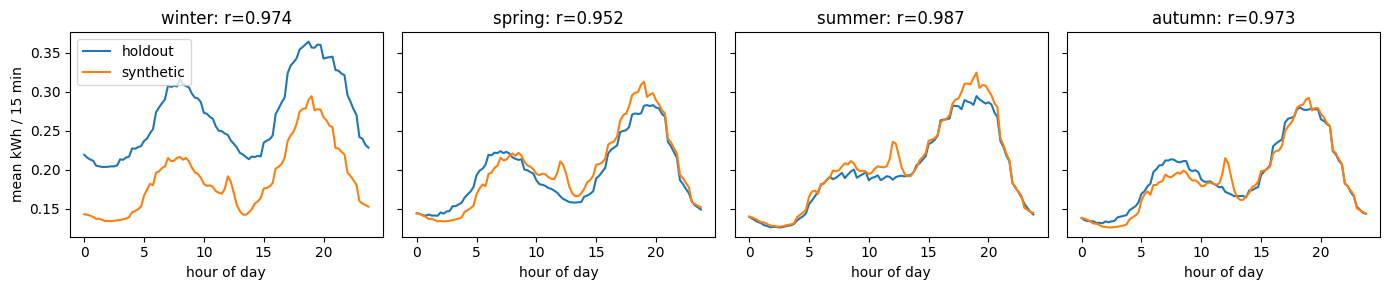

In [5]:
from opensynth.evaluation.fidelity.shape_metrics import (
    shape_correlation,
    shape_rmse,
)

SEASONS = {
    "winter": (12, 1, 2),
    "spring": (3, 4, 5),
    "summer": (6, 7, 8),
    "autumn": (9, 10, 11),
}
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
shape_rows = []
hours = np.arange(96) / 4
for ax, (season, ms) in zip(axes, SEASONS.items()):
    mask = np.isin(months, ms)
    real_mean = holdout_kwh[mask].mean(axis=0)
    synth_mean = synth_kwh[mask].mean(axis=0)
    r = shape_correlation(real_mean, synth_mean)
    rmse = shape_rmse(real_mean, synth_mean)
    shape_rows.append(
        {"season": season, "r": r, "rmse": rmse, "pass": bool(r > 0.85)}
    )
    ax.plot(hours, real_mean, label="holdout")
    ax.plot(hours, synth_mean, label="synthetic")
    ax.set_title(f"{season}: r={r:.3f}")
    ax.set_xlabel("hour of day")
axes[0].set_ylabel("mean kWh / 15 min")
axes[0].legend()
plt.tight_layout()
shape_df = pl.DataFrame(shape_rows)
print(shape_df)
crit3_pass = bool(shape_df["pass"].all())

## Criterion 4 — EV evening signature

Same home either side of the `has_ev` flag: EV homes should shift energy share into the
16–23 h charging window. Caveat: the RECS-honest training mix contains only ~13 EV homes, so
this signature rides on very little data — a documented EV oversample is the open
alternative if it proves too weak.

Evening (16-23h) energy share: EV 0.466 vs non-EV 0.353
Daily mean: EV 42.3 kWh vs non-EV 23.7 kWh


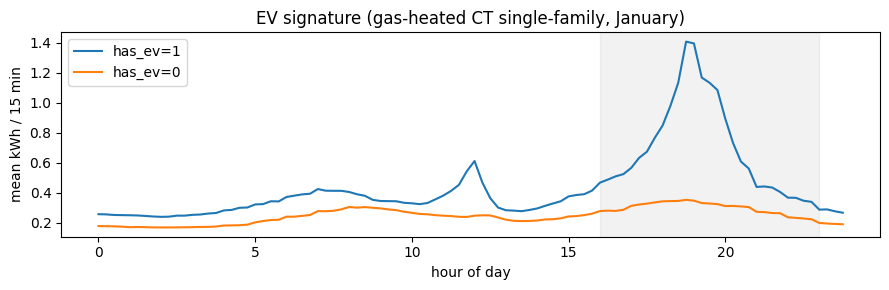

In [6]:
from opensynth.evaluation.fidelity.shape_metrics import energy_window_share

base = {
    "state": 0,
    "archetype": 0,
    "heating_fuel": 1,
    "has_pv": 0,
    "month": 1,
    "dayofweek": 2,
    "temp_bin": 3,
}
with torch.no_grad():
    ev = model.sample_gmm_conditional({**base, "has_ev": 1}, 1024)
    no_ev = model.sample_gmm_conditional({**base, "has_ev": 0}, 1024)
ev_kwh = (ev["kwh"].numpy() * KWH_STD + KWH_MEAN).clip(min=0)
no_ev_kwh = (no_ev["kwh"].numpy() * KWH_STD + KWH_MEAN).clip(min=0)

ev_share = energy_window_share(ev_kwh)
no_ev_share = energy_window_share(no_ev_kwh)
print(f"Evening (16-23h) energy share: EV {ev_share:.3f} vs non-EV {no_ev_share:.3f}")
print(
    f"Daily mean: EV {ev_kwh.sum(axis=1).mean():.1f} kWh "
    f"vs non-EV {no_ev_kwh.sum(axis=1).mean():.1f} kWh"
)
crit4_pass = bool(ev_share > no_ev_share)

fig, ax = plt.subplots(figsize=(9, 3))
hours = np.arange(96) / 4
ax.plot(hours, ev_kwh.mean(axis=0), label="has_ev=1")
ax.plot(hours, no_ev_kwh.mean(axis=0), label="has_ev=0")
ax.axvspan(16, 23, alpha=0.1, color="grey")
ax.set_xlabel("hour of day")
ax.set_ylabel("mean kWh / 15 min")
ax.set_title("EV signature (gas-heated CT single-family, January)")
ax.legend()
plt.tight_layout()

## Criterion 5 — PV signature

Two layers. **Source level** (done at shape-build time, `scripts/fetch_pv_shapes.py`): the
Open-Meteo 2018 PVWatts-model shapes agree with the PVGIS-NSRDB 2005–2015 climatology — the
same radiation database the PVWatts API uses — at profile r ≈ 0.98 and annual energy within
7–9 %, i.e. inside the ±10 % intent of the original criterion. **Model level** (here): a
sunny July `has_pv` home should show a clear midday net-load depression vs its non-PV twin
(~104 PV homes in training; mean system ~6 kW at ~0.45 kW/kW midday ≈ −0.6 kWh per 15 min).

Midday (10-16h) mean net load: PV -0.040 vs non-PV 0.255 kWh/15min
Midday depression: -0.295 kWh/15min


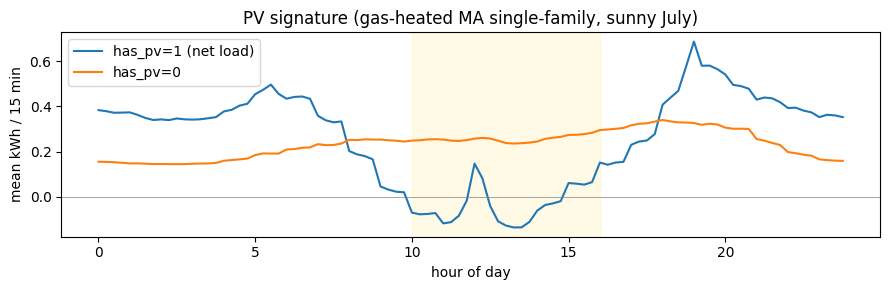

In [7]:
base = {
    "state": 1,
    "archetype": 0,
    "heating_fuel": 1,
    "has_ev": 0,
    "month": 7,
    "dayofweek": 2,
    "temp_bin": 7,
}
with torch.no_grad():
    pv = model.sample_gmm_conditional({**base, "has_pv": 1}, 1024)
    no_pv = model.sample_gmm_conditional({**base, "has_pv": 0}, 1024)
pv_kwh = pv["kwh"].numpy() * KWH_STD + KWH_MEAN  # net load, may go negative
no_pv_kwh = (no_pv["kwh"].numpy() * KWH_STD + KWH_MEAN).clip(min=0)

MIDDAY = slice(10 * 4, 16 * 4)
midday_delta = float(
    pv_kwh[:, MIDDAY].mean() - no_pv_kwh[:, MIDDAY].mean()
)
print(
    f"Midday (10-16h) mean net load: PV {pv_kwh[:, MIDDAY].mean():.3f} "
    f"vs non-PV {no_pv_kwh[:, MIDDAY].mean():.3f} kWh/15min"
)
print(f"Midday depression: {midday_delta:+.3f} kWh/15min")
crit5_pass = bool(midday_delta < -0.1)

fig, ax = plt.subplots(figsize=(9, 3))
hours = np.arange(96) / 4
ax.plot(hours, pv_kwh.mean(axis=0), label="has_pv=1 (net load)")
ax.plot(hours, no_pv_kwh.mean(axis=0), label="has_pv=0")
ax.axhline(0, color="grey", lw=0.5)
ax.axvspan(10, 16, alpha=0.1, color="gold")
ax.set_xlabel("hour of day")
ax.set_ylabel("mean kWh / 15 min")
ax.set_title("PV signature (gas-heated MA single-family, sunny July)")
ax.legend()
plt.tight_layout()

## Framework fidelity — seasonal peaks and autocorrelation (Chai et al. §III-D)

The repo's existing benchmark tooling compares **year-long per-home series** in wide format.
Our synthetic years are stitched from conditionally-sampled days, so day-to-day coherence
enters only through the shared real 2018 temp-bin trajectory — the `autocorrelation` module's
own docstring notes independent-day models are not expected to excel at long-lag ACF. Running
it anyway quantifies exactly how much coherence the trajectory conditioning buys.

   statistic       p_value  season
0       0.77  1.923610e-29  spring
1       0.42  2.749465e-08  summer
2       0.27  1.293506e-03    fall
3       0.45  1.704797e-09  winter


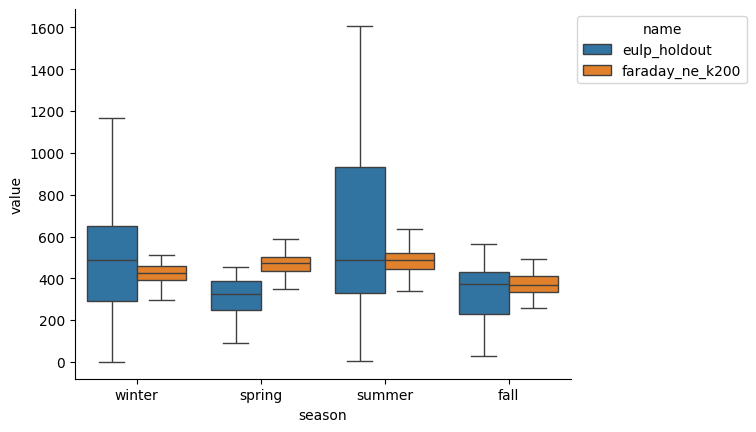

In [8]:
from opensynth.evaluation.fidelity.autocorrelation import (
    calculate_auto_correlation,
    pairwise_autocorrelation_kstest,
    plot_autocorrelation_stats,
)
from opensynth.evaluation.fidelity.seasonal_statistics import (
    calculate_seasonal_peaks,
    pairwise_seasonal_kstest,
    plot_seasonal_stats,
)

N_FRAMEWORK_HOMES = 100


def year_wide(kwh_arr, rows, homes_sel):
    """Wide year-long frame: 15-min timestamps x homes."""
    pdf = rows.select(["ID", "date"]).to_pandas()
    pdf["date"] = pd.to_datetime(pdf["date"])
    cols = {}
    for home in homes_sel:
        idx = np.flatnonzero((pdf["ID"] == home).to_numpy())
        idx = idx[np.argsort(pdf["date"].iloc[idx].to_numpy())]
        assert len(idx) == 365
        cols[str(home)] = kwh_arr[idx].ravel()
    out = pd.DataFrame(
        cols, index=pd.date_range("2018-01-01", periods=365 * 96, freq="15min")
    )
    out.index.name = "datetime"
    return out


sel_homes = home_ids[:N_FRAMEWORK_HOMES]
benchmark_set = {
    "eulp_holdout": year_wide(holdout_kwh, holdout, sel_homes),
    f"faraday_ne_k{GMM_K}": year_wide(synth_kwh, holdout, sel_homes),
}

peaks = calculate_seasonal_peaks(benchmark_set)
plot_seasonal_stats(peaks)
peaks_ks = pairwise_seasonal_kstest(
    peaks, "eulp_holdout", f"faraday_ne_k{GMM_K}"
)
print(peaks_ks)

   statistic       p_value time_delta
0       0.71  1.587524e-24       hour
1       0.76  1.418662e-28   half_day
2       0.68  2.620711e-22        day
3       0.65  3.108080e-20       week
4       0.27  1.293506e-03  half_year


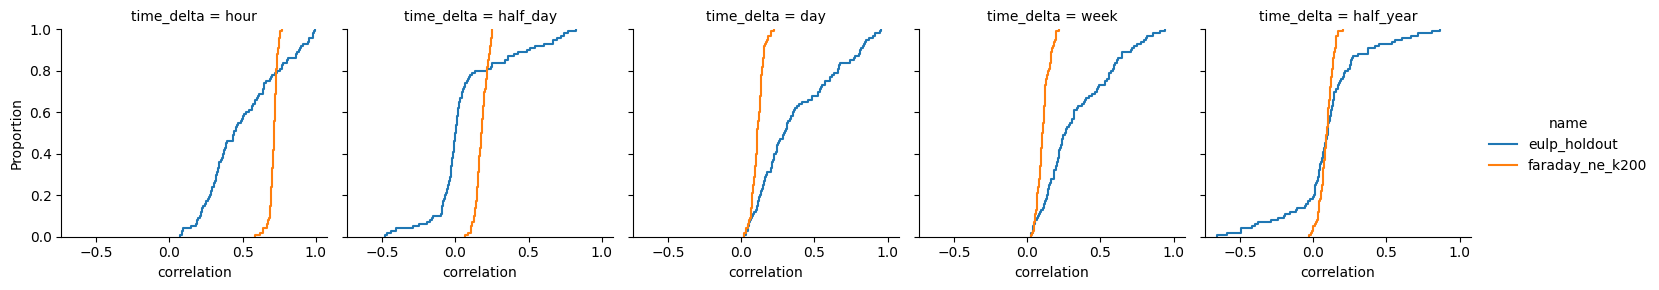

In [9]:
acf = calculate_auto_correlation(benchmark_set)
plot_autocorrelation_stats(acf)
acf_ks = pairwise_autocorrelation_kstest(
    acf, "eulp_holdout", f"faraday_ne_k{GMM_K}"
)
print(acf_ks)

## Framework utility — TSTR season classification (Chai et al. §III-E)

Train-on-Synthetic-Test-on-Real: the paper's season-classification task (Winter/Spring =
Dec–May vs Summer/Autumn = Jun–Nov) on daily profiles. A classifier trained on synthetic days
should score close to one trained on real training-split days when both are tested on real
holdout days; the *absolute accuracy delta* is the utility measure.

In [10]:
from sklearn.linear_model import LogisticRegression

WINTER_SPRING = (12, 1, 2, 3, 4, 5)


def season_targets(month_arr):
    return np.isin(month_arr, WINTER_SPRING).astype(int)


real_train = (
    pl.scan_csv(DATA_DIR / "processed/new_england/train/data.csv")
    .select(["month", "kwh"])
    .gather_every(24)
    .collect()
)
real_train_kwh = np.array([ast.literal_eval(s) for s in real_train["kwh"]])

X_test, y_test = holdout_kwh, season_targets(months)

tstr = LogisticRegression(max_iter=2000).fit(synth_kwh, season_targets(months))
trtr = LogisticRegression(max_iter=2000).fit(
    real_train_kwh, season_targets(real_train["month"].to_numpy())
)

acc_tstr = tstr.score(X_test, y_test)
acc_trtr = trtr.score(X_test, y_test)
print(f"TSTR accuracy (train synthetic): {acc_tstr:.3f}")
print(f"TRTR accuracy (train real):      {acc_trtr:.3f}")
print(f"Absolute delta:                  {abs(acc_trtr - acc_tstr):.3f}")

TSTR accuracy (train synthetic): 0.572
TRTR accuracy (train real):      0.575
Absolute delta:                  0.002


## Framework privacy — why v1 carries no personal data

The framework's privacy dimension (membership inference, reconstruction attacks, the
outlier-poisoning method — all implemented in `opensynth.evaluation.privacy`) targets models
trained on **real household meter data**. This model is trained on NREL ResStock *simulated*
buildings: no real household appears anywhere in the pipeline, so there is no personal data
to leak and GDPR-style privacy risk does not arise. The dataset card states this explicitly.
The privacy tooling becomes mandatory the moment this pipeline is retrained on real AMI data.

## Summary

Metrics are saved next to the checkpoints for the dataset card; rerun the notebook with a
different `GMM_K` to compare sweep values.

In [11]:
summary = pl.DataFrame(
    {
        "criterion": [
            "annual kWh vs RECS (±5%)",
            "peak timing vs ISO-NE (60 min)",
            "seasonal shape r > 0.85",
            "EV evening uplift",
            "PV midday signature",
        ],
        "result": [
            f"MPE {mpe_recs:+.1f}%",
            f"max delta {peak_df['delta_min'].max():.0f} min",
            f"min r {shape_df['r'].min():.3f}",
            f"{ev_share:.3f} vs {no_ev_share:.3f}",
            f"midday delta {midday_delta:+.3f} kWh/15min",
        ],
        "pass": [crit1_pass, crit2_pass, crit3_pass, crit4_pass, crit5_pass],
    }
)
print(summary)

metrics = {
    "gmm_k": GMM_K,
    "n_eval_homes": N_HOMES,
    "mpe_vs_recs_pct": mpe_recs,
    "mpe_vs_holdout_pct": mpe_holdout,
    "ks_vs_recs": ks,
    "peak_timing": peak_rows,
    "shape": shape_rows,
    "ev_evening_share": {"ev": ev_share, "non_ev": no_ev_share},
    "pv_midday_delta_kwh_15min": midday_delta,
    "framework": {
        "seasonal_peaks_ks": peaks_ks.to_dict("records"),
        "acf_ks": acf_ks.to_dict("records"),
        "tstr_accuracy": acc_tstr,
        "trtr_accuracy": acc_trtr,
        "tstr_abs_delta": abs(acc_trtr - acc_tstr),
    },
}
out_path = MODEL_DIR / f"eval_metrics_k{GMM_K}.json"
out_path.write_text(json.dumps(metrics, indent=2))
print("Saved", out_path)

shape: (5, 3)
┌────────────────────────────────┬───────────────────────────────┬───────┐
│ criterion                      ┆ result                        ┆ pass  │
│ ---                            ┆ ---                           ┆ ---   │
│ str                            ┆ str                           ┆ bool  │
╞════════════════════════════════╪═══════════════════════════════╪═══════╡
│ annual kWh vs RECS (±5%)       ┆ MPE -5.9%                     ┆ false │
│ peak timing vs ISO-NE (60 min) ┆ max delta 60 min              ┆ true  │
│ seasonal shape r > 0.85        ┆ min r 0.952                   ┆ true  │
│ EV evening uplift              ┆ 0.466 vs 0.353                ┆ true  │
│ PV midday signature            ┆ midday delta -0.295 kWh/15min ┆ true  │
└────────────────────────────────┴───────────────────────────────┴───────┘
Saved ../../data/models/new_england/eval_metrics_k200.json
